# Workforce Attrition Analysis

## Project Overview
This analysis examines workforce attrition patterns to identify employee groups associated with elevated turnover risk. Using Python and pandas, the analysis explores relationships between attrition and overtime, job role, compensation, tenure, and job satisfaction.

### Business Questions
- What is the overall employee attrition rate?
- Is overtime associated with higher attrition?
- Which job roles experience the highest attrition?
- Does the relationship between overtime and attrition vary by job role?
- How does compensation differ between employees who stay and leave?
- Is attrition concentrated among employees with shorter tenure?
- How does job satisfaction relate to attrition?

### Dataset
The dataset contains 1,470 employee records and 35 original variables covering demographics, compensation, job characteristics, satisfaction, tenure, and attrition.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

## 1. Data Preparation and Validation

In [2]:
df = pd.read_csv("HR-Employee-Attrition.csv")

### Initial Data Inspection

Review the dataset dimensions, column data types, and completeness before beginning the analysis.

In [5]:
df.shape

(1470, 35)

In [7]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

### Data Quality Checks

Check for duplicate records and examine unique values across columns to identify variables that may not provide analytical value.

In [9]:
df.duplicated().sum()


0

In [11]:
df.nunique()

Age                           43
Attrition                      2
BusinessTravel                 3
DailyRate                    886
Department                     3
DistanceFromHome              29
Education                      5
EducationField                 6
EmployeeCount                  1
EmployeeNumber              1470
EnvironmentSatisfaction        4
Gender                         2
HourlyRate                    71
JobInvolvement                 4
JobLevel                       5
JobRole                        9
JobSatisfaction                4
MaritalStatus                  3
MonthlyIncome               1349
MonthlyRate                 1427
NumCompaniesWorked            10
Over18                         1
OverTime                       2
PercentSalaryHike             15
PerformanceRating              2
RelationshipSatisfaction       4
StandardHours                  1
StockOptionLevel               4
TotalWorkingYears             40
TrainingTimesLastYear          7
WorkLifeBa

### Data Cleaning

Three constant columns—`EmployeeCount`, `Over18`, and `StandardHours`—were removed because each contained only one unique value and therefore provided no meaningful variation for the analysis.

In [13]:
df = df.drop(columns=['EmployeeCount', 'Over18', 'StandardHours'])

In [15]:
df.shape

(1470, 32)

In [19]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeNumber,EnvironmentSatisfaction,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,2,...,3,1,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,2,3,...,4,4,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,4,4,...,3,2,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,5,4,...,3,3,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,7,1,...,3,4,1,6,3,3,2,2,2,2


## 2. Exploratory Workforce Analysis

With the dataset validated and non-informative constant variables removed, the analysis now examines overall employee attrition and begins identifying workforce characteristics associated with turnover.

### Overall Employee Attrition

First, examine the number and percentage of employees who remained with the organization versus those who left.

In [21]:
df['Attrition'].value_counts()


No     1233
Yes     237
Name: Attrition, dtype: int64

In [23]:
df['Attrition'].value_counts(normalize=True) * 100

No     83.877551
Yes    16.122449
Name: Attrition, dtype: float64

### Key Finding

Of the 1,470 employees in the dataset, 237 employees left the organization, resulting in an overall attrition rate of approximately **16.1%**. This rate serves as the baseline for evaluating whether specific workforce groups experience disproportionately higher levels of attrition.

### Overtime and Attrition

To determine whether overtime is associated with employee turnover, attrition rates were compared between employees who work overtime and those who do not.

In [25]:
pd.crosstab(df['OverTime'], df['Attrition'])

Attrition,No,Yes
OverTime,,
No,944,110
Yes,289,127


In [35]:
overtime_attrition = pd.crosstab(
    df['OverTime'],
    df['Attrition'],
    normalize='index'
) * 100

In [37]:
overtime_attrition

Attrition,No,Yes
OverTime,,
No,89.563567,10.436433
Yes,69.471154,30.528846


#### Key Finding

Employees who worked overtime experienced an attrition rate of approximately **30.5%**, compared with **10.4%** among employees who did not work overtime. This means the attrition rate among employees working overtime was nearly **three times higher**.

Although this analysis does not establish that overtime causes employee turnover, the substantial difference identifies overtime as an important workforce risk indicator for further investigation.

#### Overtime Attrition Visualization

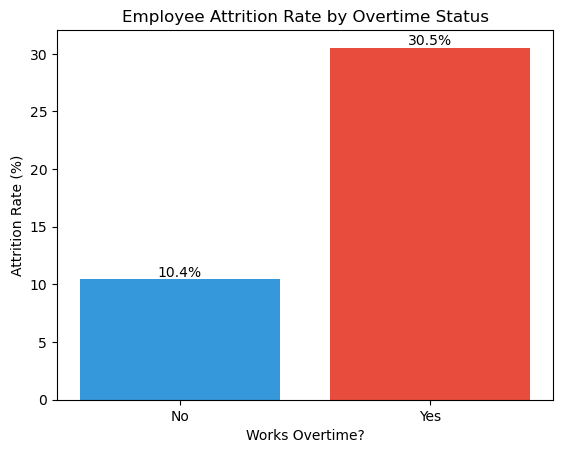

In [43]:
# 1. Draw the bars using our Index (X) and 'Yes' column (Y)
bars = plt.bar(overtime_attrition.index, overtime_attrition['Yes'], color=['#3498db', '#e74c3c'])

# 2. Add labels so leadership knows exactly what they are looking at
plt.title('Employee Attrition Rate by Overtime Status')
plt.xlabel('Works Overtime?')
plt.ylabel('Attrition Rate (%)')

plt.bar_label(bars, fmt='%.1f%%')

# 3. Render the chart
plt.show()

### Job Role and Attrition

To identify whether turnover risk is concentrated within specific areas of the workforce, attrition rates were compared across job roles.

In [45]:
pd.crosstab(
    df['JobRole'],
    df['Attrition'],
    normalize='index'
) * 100

Attrition,No,Yes
JobRole,,
Healthcare Representative,93.129771,6.870229
Human Resources,76.923077,23.076923
Laboratory Technician,76.061776,23.938224
Manager,95.098039,4.901961
Manufacturing Director,93.103448,6.896552
Research Director,97.500000,2.500000
Research Scientist,83.904110,16.095890
Sales Executive,82.515337,17.484663
Sales Representative,60.240964,39.759036


#### Key Finding

Attrition varies substantially across job roles. **Sales Representatives had the highest attrition rate at approximately 39.8%**, nearly 2.5 times the company-wide rate of 16.1%. Laboratory Technicians (23.9%) and Human Resources employees (23.1%) also experienced elevated attrition.

In contrast, Research Directors had the lowest observed attrition rate at approximately **2.5%**, indicating that turnover risk is concentrated more heavily within certain workforce segments rather than being evenly distributed across the organization.

### Interaction Between Job Role and Overtime

Because both overtime status and job role were individually associated with differences in attrition, the analysis next examines whether the relationship between overtime and attrition varies across job roles.

In [47]:
pd.crosstab(
    [df['JobRole'], df['OverTime']],
    df['Attrition'],
    normalize='index'
) * 100

Attrition                                  No        Yes
JobRole                   OverTime                      
Healthcare Representative No        92.553191   7.446809
                          Yes       94.594595   5.405405
Human Resources           No        82.051282  17.948718
                          Yes       61.538462  38.461538
Laboratory Technician     No        84.263959  15.736041
                          Yes       50.000000  50.000000
Manager                   No        98.666667   1.333333
                          Yes       85.185185  14.814815
Manufacturing Director    No        94.339623   5.660377
                          Yes       89.743590  10.256410
Research Director         No        98.245614   1.754386
                          Yes       95.652174   4.347826
Research Scientist        No        92.820513   7.179487
                          Yes       65.979381  34.020619
Sales Executive           No        88.793103  11.206897
                          Yes       67.021277  32.978723
Sales Representative      No        71.186441  28.813559
                          Yes       33.333333  66.666667

#### Key Finding

The relationship between overtime and attrition varies substantially across job roles. The most pronounced difference appears among **Sales Representatives**, where employees working overtime had an attrition rate of approximately **66.7%**, compared with **28.8%** among Sales Representatives who did not work overtime.

Elevated overtime attrition also appears among several other roles, including Laboratory Technicians, Human Resources employees, Research Scientists, and Sales Executives. These results suggest that overtime may represent a particularly important workforce risk indicator within certain job functions rather than affecting all roles equally.

### Compensation and Attrition

To examine whether compensation differs between employees who remain with the organization and those who leave, average monthly income was compared by attrition status.

In [49]:
df.groupby('Attrition')['MonthlyIncome'].mean()


Attrition
No     6832.739659
Yes    4787.092827
Name: MonthlyIncome, dtype: float64

#### Initial Finding

Employees who left the organization had an average monthly income of approximately **$4,787**, compared with **$6,833** among employees who remained. At the company level, employees who left therefore earned approximately **30% less on average**.

However, because compensation varies substantially by job role, this aggregate difference does not necessarily indicate that lower compensation within a given role is associated with higher attrition. A role-level comparison is needed before drawing that conclusion.

#### Compensation by Job Role

To account for differences in compensation across job functions, average monthly income was further compared by both job role and attrition status.

In [51]:
df.groupby(['JobRole', 'Attrition'])['MonthlyIncome'].mean()


JobRole                    Attrition
Healthcare Representative  No            7453.557377
                           Yes           8548.222222
Human Resources            No            4391.750000
                           Yes           3715.750000
Laboratory Technician      No            3337.223350
                           Yes           2919.258065
Manager                    No           17201.484536
                           Yes          16797.400000
Manufacturing Director     No            7289.925926
                           Yes           7365.500000
Research Director          No           15947.346154
                           Yes          19395.500000
Research Scientist         No            3328.122449
                           Yes           2780.468085
Sales Executive            No            6804.617100
                           Yes           7489.000000
Sales Representative       No            2798.440000
                           Yes           2364.727273
Name: Mon

#### Key Finding

The role-level analysis reveals that the relationship between compensation and attrition is **not consistent across job roles**. In several roles—including Human Resources, Laboratory Technician, Research Scientist, and Sales Representative—employees who left earned less on average than employees who remained.

However, the opposite pattern appears in other roles. For example, departing Healthcare Representatives and Sales Executives had higher average monthly incomes than employees who remained in those same roles.

These results suggest that the lower average income observed among employees who left at the company level is influenced partly by the distribution of attrition across job roles. **Compensation alone does not provide a sufficient explanation for employee attrition in this dataset.**

### Tenure and Attrition

To determine whether attrition is concentrated among employees with shorter organizational tenure, average years at the company were compared by attrition status.

In [53]:
df.groupby('Attrition')['YearsAtCompany'].mean()

Attrition
No     7.369019
Yes    5.130802
Name: YearsAtCompany, dtype: float64

#### Initial Finding

Employees who left the organization had worked at the company for an average of approximately **5.1 years**, compared with **7.4 years** among employees who remained.

This suggests that employees who leave tend to have shorter organizational tenure. However, an average alone can conceal where attrition is most concentrated, so tenure was examined at the individual year level.

#### Attrition Distribution by Years at Company

The number of employees who left was examined across individual tenure years to identify where departures were concentrated.

In [55]:
df[df['Attrition'] == 'Yes']['YearsAtCompany'].value_counts().sort_index()

0     16
1     59
2     27
3     20
4     19
5     21
6      9
7     11
8      9
9      8
10    18
11     2
13     2
14     2
15     1
16     1
17     1
18     1
19     1
20     1
21     1
22     1
23     1
24     1
31     1
32     1
33     1
40     1
Name: YearsAtCompany, dtype: int64

#### Attrition Rate by Years at Company

Because departure counts alone do not account for the number of employees at each tenure level, attrition rates were calculated within each year-at-company group.

In [57]:
pd.crosstab(
    df['YearsAtCompany'],
    df['Attrition'],
    normalize='index'
) * 100

Attrition,No,Yes
YearsAtCompany,,
0,63.636364,36.363636
1,65.497076,34.502924
2,78.740157,21.259843
3,84.375000,15.625000
4,82.727273,17.272727
5,89.285714,10.714286
6,88.157895,11.842105
7,87.777778,12.222222
8,88.750000,11.250000


#### Key Finding

Attrition is most concentrated during the earliest stages of employee tenure. Employees with less than one year at the company experienced an attrition rate of approximately **36.4%**, while employees with one year of tenure experienced a similarly high rate of **34.5%**. By two years, the attrition rate declined to approximately **21.3%**, followed by **15.6%** at three years.

Combined with the average-tenure analysis, these results suggest that the organization's greatest retention vulnerability occurs relatively early in the employee lifecycle.

Some long-tenure groups also display high attrition percentages; however, these groups contain substantially fewer employees. Their percentages should therefore be interpreted cautiously because a very small number of departures can produce an unusually high attrition rate.

#### Tenure Group Analysis

To reduce volatility among individual tenure years and provide a more meaningful business comparison, employees were grouped into broader tenure categories. Attrition rates were then calculated within each tenure group.

In [61]:
df['TenureGroup'] = pd.cut(
    df['YearsAtCompany'],
    bins=[-1, 0, 2, 5, 10, float('inf')],
    labels=['<1 Year', '1-2 Years', '3-5 Years', '6-10 Years', '11+ Years']
)

pd.crosstab(
    df['TenureGroup'],
    df['Attrition'],
    normalize='index'
) * 100

Attrition,No,Yes
TenureGroup,,
<1 Year,63.636364,36.363636
1-2 Years,71.140940,28.859060
3-5 Years,86.175115,13.824885
6-10 Years,87.723214,12.276786
11+ Years,91.869919,8.130081


#### Key Finding

The tenure-group analysis reveals a clear pattern of declining attrition as organizational tenure increases. Employees with less than one year at the company experienced the highest attrition rate at approximately **36.4%**, followed by **28.9%** among employees with one to two years of tenure.

Attrition fell substantially to **13.8%** among employees with three to five years of tenure and continued declining to **12.3%** among employees with six to ten years and **8.1%** among employees with more than ten years of service.

Employees in their first year therefore experienced an attrition rate more than **four times higher** than employees with over ten years of tenure. This pattern identifies the early employee lifecycle as a particularly important area for further retention analysis, including onboarding, role expectations, workload, compensation, and early-career support.

### Job Satisfaction and Attrition

To evaluate whether employee sentiment is associated with turnover, attrition rates were compared across job satisfaction levels ranging from 1 (lowest satisfaction) to 4 (highest satisfaction).

In [59]:
pd.crosstab(
    df['JobSatisfaction'],
    df['Attrition'],
    normalize='index'
) * 100

Attrition,No,Yes
JobSatisfaction,,
1,77.162630,22.837370
2,83.571429,16.428571
3,83.484163,16.515837
4,88.671024,11.328976


#### Key Finding and Business Recommendation

Job satisfaction demonstrates a clear association with employee attrition. Employees reporting the lowest satisfaction level experienced an attrition rate of approximately **22.8%**, compared with **11.3%** among employees reporting the highest satisfaction level. While satisfaction scores should be interpreted as correlational indicators rather than direct causes of departure, the pattern suggests that declining employee sentiment may provide a useful signal for identifying elevated retention risk.

Leadership could consider implementing a structured employee-listening and retention process in which low satisfaction scores—particularly Levels 1 and 2—trigger an HR or manager check-in. A **90-day retention follow-up** could then be piloted to better understand concerns related to workload, career development, role expectations, compensation, or other aspects of the employee experience.

The effectiveness of this intervention should be measured over time by comparing subsequent satisfaction scores and retention outcomes among participating employees. This would allow the organization to determine whether targeted early intervention is associated with improved employee retention.

## 3. Executive Findings and Recommendations

The workforce analysis identified several employee characteristics associated with elevated attrition risk. Overall employee attrition was approximately **16.1%**, but the risk was not distributed evenly across the workforce.

### Key Findings

- **Overtime:** Employees working overtime experienced approximately **30.5% attrition**, nearly three times the **10.4%** rate among employees who did not work overtime.
- **Job Role:** Sales Representatives experienced the highest overall attrition rate at approximately **39.8%**, substantially above the company-wide baseline.
- **Job Role + Overtime:** Sales Representatives working overtime experienced approximately **66.7% attrition**, identifying this combination as a particularly high-risk workforce segment.
- **Compensation:** Employees who left earned lower monthly income on average than employees who remained, although differences varied considerably across job roles.
- **Tenure:** Attrition was concentrated early in the employee lifecycle. Employees with less than one year of tenure experienced approximately **36.4% attrition**, compared with **8.1%** among employees with more than ten years of service.
- **Job Satisfaction:** Employees reporting the lowest job satisfaction experienced approximately **22.8% attrition**, compared with **11.3%** among employees reporting the highest satisfaction.

### Business Recommendations

Leadership should prioritize further investigation of high-risk workforce segments rather than relying solely on the company-wide attrition rate. Particular attention should be given to overtime practices within high-turnover roles, early-tenure employee experiences, compensation structures, and employee satisfaction.

Potential retention initiatives should be implemented as measurable interventions. Outcomes can then be monitored over time to determine whether changes in workload, onboarding, career development, compensation, or employee-listening practices are associated with improved retention.

### Analytical Limitation

This analysis identifies associations within the available workforce data and should not be interpreted as establishing causal relationships. Additional longitudinal data, employee feedback, and operational context would be required to determine why employees leave and evaluate the effectiveness of specific retention interventions.

In [63]:
df.to_csv('workforce_attrition_cleaned.csv', index=False)